In [300]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix



In [301]:
import numpy as np
import pyreadstat
demo,meta = pyreadstat.read_xport("DEMO_I.XPT")
demo.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHREDU,DMDHRMAR,DMDHSEDU,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,83732.0,9.0,2.0,1.0,62.0,NaN,3.0,3.0,1.0,NaN,...,5.0,1.0,3.0,134671.370419,135629.507405,1.0,125.0,10.0,10.0,4.39
1,83733.0,9.0,2.0,1.0,53.0,NaN,3.0,3.0,1.0,NaN,...,3.0,3.0,NaN,24328.560239,25282.425927,1.0,125.0,4.0,4.0,1.32
2,83734.0,9.0,2.0,1.0,78.0,NaN,3.0,3.0,2.0,NaN,...,3.0,1.0,3.0,12400.008522,12575.838818,1.0,131.0,5.0,5.0,1.51
3,83735.0,9.0,2.0,2.0,56.0,NaN,3.0,3.0,2.0,NaN,...,5.0,6.0,NaN,102717.995647,102078.634508,1.0,131.0,10.0,10.0,5.00
4,83736.0,9.0,2.0,2.0,42.0,NaN,4.0,4.0,2.0,NaN,...,4.0,3.0,NaN,17627.674984,18234.736219,2.0,126.0,7.0,7.0,1.23


In [302]:
import pyreadstat
smoke,meta = pyreadstat.read_xport("SMQ_I.XPT")
smoke.head()


,SEQN,SMQ020,SMD030,SMQ040,SMQ050Q,SMQ050U,SMD055,SMD057,SMQ078,SMD641,...,SMQ930,SMQ935,SMQ080,SMQ890,SMQ895,SMQ900,SMQ905,SMQ910,SMQ915,SMAQUEX2
0,83732.0,1.0,22.0,3.0,22.0,4.0,40.0,20.0,NaN,NaN,...,NaN,NaN,NaN,2.0,NaN,2.0,NaN,1.0,0.0,1.0
1,83733.0,1.0,20.0,1.0,NaN,NaN,NaN,NaN,2.0,30.0,...,NaN,NaN,NaN,1.0,30.0,2.0,NaN,2.0,NaN,1.0
2,83734.0,1.0,14.0,3.0,16.0,4.0,61.0,30.0,NaN,NaN,...,NaN,NaN,NaN,1.0,0.0,2.0,NaN,1.0,0.0,1.0
3,83735.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.0,3.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0
4,83736.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,7.0,2.0,NaN,2.0,NaN,1.0


In [303]:
import pyreadstat
chol, meta = pyreadstat.read_xport("TCHOL_I.XPT")
chol.head()


,SEQN,LBXTC,LBDTCSI
0,83732.0,173.0,4.47
1,83733.0,265.0,6.85
2,83734.0,229.0,5.92
3,83735.0,174.0,4.50
4,83736.0,204.0,5.28


In [304]:
import pyreadstat
bp, meta = pyreadstat.read_xport("BPX_I.XPT")
bp.head()


,SEQN,PEASCCT1,BPXCHR,BPAARM,BPACSZ,BPXPLS,BPXPULS,BPXPTY,BPXML1,BPXSY1,...,BPAEN1,BPXSY2,BPXDI2,BPAEN2,BPXSY3,BPXDI3,BPAEN3,BPXSY4,BPXDI4,BPAEN4
0,83732.0,NaN,NaN,1.0,4.0,76.0,1.0,1.0,150.0,128.0,...,2.0,124.0,64.0,2.0,116.0,62.0,2.0,NaN,NaN,NaN
1,83733.0,NaN,NaN,1.0,4.0,72.0,1.0,1.0,170.0,146.0,...,2.0,140.0,88.0,2.0,134.0,82.0,2.0,NaN,NaN,NaN
2,83734.0,NaN,NaN,1.0,4.0,56.0,1.0,1.0,160.0,138.0,...,2.0,132.0,44.0,2.0,136.0,46.0,2.0,NaN,NaN,NaN
3,83735.0,NaN,NaN,1.0,5.0,78.0,1.0,1.0,150.0,132.0,...,2.0,134.0,68.0,2.0,136.0,70.0,2.0,NaN,NaN,NaN
4,83736.0,NaN,NaN,1.0,3.0,76.0,1.0,1.0,130.0,100.0,...,2.0,114.0,54.0,2.0,98.0,56.0,2.0,NaN,NaN,NaN


In [305]:
import pyreadstat
body, meta = pyreadstat.read_xport("BMX_I.XPT")
body.head()


,SEQN,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,...,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXSAD1,BMXSAD2,BMXSAD3,BMXSAD4,BMDAVSAD,BMDSADCM
0,83732.0,1.0,94.8,NaN,NaN,NaN,NaN,NaN,184.5,NaN,...,35.9,NaN,101.1,NaN,22.9,22.7,NaN,NaN,22.8,NaN
1,83733.0,1.0,90.4,NaN,NaN,NaN,NaN,NaN,171.4,NaN,...,33.2,NaN,107.9,NaN,27.5,27.1,NaN,NaN,27.3,NaN
2,83734.0,1.0,83.4,NaN,NaN,NaN,NaN,NaN,170.1,NaN,...,31.0,NaN,116.5,NaN,26.7,26.5,NaN,NaN,26.6,NaN
3,83735.0,1.0,109.8,NaN,NaN,NaN,NaN,NaN,160.9,NaN,...,38.3,NaN,110.1,NaN,25.2,25.0,NaN,NaN,25.1,NaN
4,83736.0,3.0,55.2,NaN,NaN,NaN,NaN,NaN,164.9,NaN,...,27.2,NaN,80.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [306]:
'''import pyreadstat
dietary, meta = pyreadstat.read_xport("DR1IFF_I.XPT")
dietary.head()'''


'import pyreadstat\ndietary, meta = pyreadstat.read_xport("DR1IFF_I.XPT")\ndietary.head()'

In [307]:
'''diet_agg = dietary.groupby("SEQN").agg({
    "DR1IKCAL": "sum",
    "DR1IPROT": "sum",
    "DR1ICARB": "sum",
    "DR1ITFAT": "sum"
}).reset_index()'''


'diet_agg = dietary.groupby("SEQN").agg({\n    "DR1IKCAL": "sum",\n    "DR1IPROT": "sum",\n    "DR1ICARB": "sum",\n    "DR1ITFAT": "sum"\n}).reset_index()'

In [308]:
import pyreadstat
glucose, meta = pyreadstat.read_xport("GLU_I.XPT")
glucose.head()


,SEQN,WTSAF2YR,LBXGLU,LBDGLUSI
0,83733.0,54722.343330,101.0,5.59
1,83734.0,25471.093699,84.0,4.66
2,83736.0,38179.510870,84.0,4.66
3,83737.0,25800.845631,107.0,5.93
4,83741.0,108751.289086,95.0,5.27


In [309]:
import pyreadstat
urine, meta = pyreadstat.read_xport("ALB_CR_I.XPT")
urine.head()


,SEQN,URXUMA,URDUMALC,URXUMS,URXUCR,URDUCRLC,URXCRS,URDACT
0,83732.0,2.5,0.0,2.5,41.0,0.0,3624.4,6.10
1,83733.0,23.2,0.0,23.2,181.0,0.0,16000.4,12.82
2,83734.0,105.0,0.0,105.0,70.0,0.0,6188.0,150.00
3,83735.0,5.8,0.0,5.8,102.0,0.0,9016.8,5.69
4,83736.0,47.6,0.0,47.6,315.0,0.0,27846.0,15.11


In [310]:
import pyreadstat
chol_HDD, meta = pyreadstat.read_xport("HDL_I.XPT")
chol_HDD.head()


,SEQN,LBDHDD,LBDHDDSI
0,83732.0,46.0,1.19
1,83733.0,63.0,1.63
2,83734.0,30.0,0.78
3,83735.0,61.0,1.58
4,83736.0,53.0,1.37


In [311]:
import pyreadstat
chol_LDL, meta= pyreadstat.read_xport("TRIGLY_I.XPT")
chol_LDL.head()


,SEQN,WTSAF2YR,LBXTR,LBDTRSI,LBDLDL,LBDLDLSI
0,83733.0,54722.343330,147.0,1.660,173.0,4.474
1,83734.0,25471.093699,269.0,3.037,145.0,3.750
2,83736.0,38179.510870,47.0,0.531,142.0,3.672
3,83737.0,25800.845631,46.0,0.519,103.0,2.664
4,83741.0,108751.289086,68.0,0.768,102.0,2.638


In [312]:
merged = (
    demo[['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'INDFMIN2']]
    .merge(body[['SEQN', 'BMXWT', 'BMXHT', 'BMXBMI']], on='SEQN', how='left')
    .merge(bp[['SEQN', 'BPXSY1', 'BPXDI1', 'BPXPLS']], on='SEQN', how='left')
    .merge(chol[['SEQN', 'LBXTC']], on='SEQN', how='left')
    .merge(chol_HDD[['SEQN', 'LBDHDD']], on='SEQN', how='left')
    .merge(glucose[['SEQN', 'LBXGLU']], on='SEQN', how='left')   
    .merge(chol_LDL[['SEQN','LBDLDL']], on='SEQN', how='left')
    .merge(urine[['SEQN','URDACT']], on='SEQN', how='left')
    .merge(smoke[['SEQN', 'SMQ020', 'SMD641']], on='SEQN', how='left')
    
)

In [313]:
print(merged.head())

      SEQN  RIDAGEYR  RIAGENDR  RIDRETH3  DMDEDUC2  INDFMIN2  BMXWT  BMXHT  \
0  83732.0      62.0       1.0       3.0       5.0      10.0   94.8  184.5   
1  83733.0      53.0       1.0       3.0       3.0       4.0   90.4  171.4   
2  83734.0      78.0       1.0       3.0       3.0       5.0   83.4  170.1   
3  83735.0      56.0       2.0       3.0       5.0      10.0  109.8  160.9   
4  83736.0      42.0       2.0       4.0       4.0       7.0   55.2  164.9   

   BMXBMI  BPXSY1  BPXDI1  BPXPLS  LBXTC  LBDHDD  LBXGLU  LBDLDL  URDACT  \
0    27.8   128.0    70.0    76.0  173.0    46.0     NaN     NaN    6.10   
1    30.8   146.0    88.0    72.0  265.0    63.0   101.0   173.0   12.82   
2    28.8   138.0    46.0    56.0  229.0    30.0    84.0   145.0  150.00   
3    42.4   132.0    72.0    78.0  174.0    61.0     NaN     NaN    5.69   
4    20.3   100.0    70.0    76.0  204.0    53.0    84.0   142.0   15.11   

   SMQ020  SMD641  
0     1.0     NaN  
1     1.0    30.0  
2     1.0     

In [314]:
df = merged.rename(columns = {
    'RIDAGEYR':'Age',
    'RIAGENDR':'Gender',
    'RIDRETH3':'Ethnicity',
    'DMDEDUC2':'Education',
    'INDFMIN2': 'Income',
    'BMXWT': 'Weight',
    'BMXHT': 'Height',
    'BMXBMI': 'BMI',
    'BPXSY1' : 'Systolic bp',
    'BPXDI1' : 'Diastolic bp',
    'BPXPLS' : 'Pulse',
    'LBXTC' : 'cholesterol',
    'LBDHDD' : 'HDL',
    'LBDLDL' : 'LDL',
    'LBXGLU':'Glucose',
    'URDACT' : 'Albumin_creatinine_ratio',
    'SMQ020': 'smoking status',
    'SMD641': 'Cigerette_last_30_days'
})
       

In [315]:
print(df.head())

      SEQN   Age  Gender  Ethnicity  Education  Income  Weight  Height   BMI  \
0  83732.0  62.0     1.0        3.0        5.0    10.0    94.8   184.5  27.8   
1  83733.0  53.0     1.0        3.0        3.0     4.0    90.4   171.4  30.8   
2  83734.0  78.0     1.0        3.0        3.0     5.0    83.4   170.1  28.8   
3  83735.0  56.0     2.0        3.0        5.0    10.0   109.8   160.9  42.4   
4  83736.0  42.0     2.0        4.0        4.0     7.0    55.2   164.9  20.3   

   Systolic bp  Diastolic bp  Pulse  cholesterol   HDL  Glucose    LDL  \
0        128.0          70.0   76.0        173.0  46.0      NaN    NaN   
1        146.0          88.0   72.0        265.0  63.0    101.0  173.0   
2        138.0          46.0   56.0        229.0  30.0     84.0  145.0   
3        132.0          72.0   78.0        174.0  61.0      NaN    NaN   
4        100.0          70.0   76.0        204.0  53.0     84.0  142.0   

   Albumin_creatinine_ratio  smoking status  Cigerette_last_30_days  
0   

In [316]:
#df.head()

In [317]:
df.shape

(9971, 19)

In [318]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9971 entries, 0 to 9970
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SEQN                      9971 non-null   float64
 1   Age                       9971 non-null   float64
 2   Gender                    9971 non-null   float64
 3   Ethnicity                 9971 non-null   float64
 4   Education                 5719 non-null   float64
 5   Income                    9642 non-null   float64
 6   Weight                    9445 non-null   float64
 7   Height                    8769 non-null   float64
 8   BMI                       8756 non-null   float64
 9   Systolic bp               7145 non-null   float64
 10  Diastolic bp              7145 non-null   float64
 11  Pulse                     7376 non-null   float64
 12  cholesterol               7256 non-null   float64
 13  HDL                       7256 non-null   float64
 14  Glucose 

In [319]:
df.isnull().sum()*0.01

SEQN                         0.00
Age                          0.00
Gender                       0.00
Ethnicity                    0.00
Education                   42.52
Income                       3.29
Weight                       5.26
Height                      12.02
BMI                         12.15
Systolic bp                 28.26
Diastolic bp                28.26
Pulse                       25.95
cholesterol                 27.15
HDL                         27.15
Glucose                     69.99
LDL                         72.72
Albumin_creatinine_ratio    16.91
smoking status              39.79
Cigerette_last_30_days      88.09
dtype: float64

In [320]:
df['Ethnicity'].value_counts()


Ethnicity
3.0    3066
4.0    2129
1.0    1921
2.0    1308
6.0    1042
7.0     505
Name: count, dtype: int64

In [321]:
df['Income'].value_counts()

Income
15.0    1548
6.0     1038
7.0      934
14.0     885
8.0      801
5.0      646
9.0      620
4.0      618
3.0      584
10.0     474
2.0      426
1.0      345
77.0     222
12.0     221
13.0     148
99.0     132
Name: count, dtype: int64

In [322]:
import pandas as pd

num_cols = df.select_dtypes(include='float64').columns
skew_values = df[num_cols].skew().sort_values(ascending=False)
skew_values


Albumin_creatinine_ratio    33.704854
Income                       4.434669
Glucose                      4.333001
smoking status               3.151306
Systolic bp                  1.070372
HDL                          1.046750
cholesterol                  0.896382
BMI                          0.859083
LDL                          0.638844
Ethnicity                    0.589184
Pulse                        0.564961
Age                          0.420322
Weight                       0.126277
SEQN                         0.000000
Gender                      -0.037521
Education                   -0.427383
Cigerette_last_30_days      -0.569048
Diastolic bp                -0.741859
Height                      -1.241887
dtype: float64

In [323]:
df.columns

Index(['SEQN', 'Age', 'Gender', 'Ethnicity', 'Education', 'Income', 'Weight',
       'Height', 'BMI', 'Systolic bp', 'Diastolic bp', 'Pulse', 'cholesterol',
       'HDL', 'Glucose', 'LDL', 'Albumin_creatinine_ratio', 'smoking status',
       'Cigerette_last_30_days'],
      dtype='object')

In [324]:
# Replace special coded value

df[['Education','smoking status']]= df[['Education','smoking status']].replace({7: np.nan, 9: np.nan, '.' : np.nan})
df[['Income','Cigerette_last_30_days']] = df[['Income','Cigerette_last_30_days']].replace({77: np.nan, 99:np.nan , '.':np.nan})

In [325]:
# Handling missing values
columns_mean=['Age','Weight']
columns_median = ['Height','BMI','Systolic bp','Diastolic bp','Pulse','cholesterol','HDL', 'LDL','Glucose','Albumin_creatinine_ratio','Cigerette_last_30_days']
df[columns_median] = df[columns_median].fillna(df[columns_median].median())
df[columns_mean] = df[columns_mean].fillna(df[columns_mean].mean())


In [326]:
df.head()

,SEQN,Age,Gender,Ethnicity,Education,Income,Weight,Height,BMI,Systolic bp,Diastolic bp,Pulse,cholesterol,HDL,Glucose,LDL,Albumin_creatinine_ratio,smoking status,Cigerette_last_30_days
0,83732.0,62.0,1.0,3.0,5.0,10.0,94.8,184.5,27.8,128.0,70.0,76.0,173.0,46.0,101.0,104.0,6.10,1.0,30.0
1,83733.0,53.0,1.0,3.0,3.0,4.0,90.4,171.4,30.8,146.0,88.0,72.0,265.0,63.0,101.0,173.0,12.82,1.0,30.0
2,83734.0,78.0,1.0,3.0,3.0,5.0,83.4,170.1,28.8,138.0,46.0,56.0,229.0,30.0,84.0,145.0,150.00,1.0,30.0
3,83735.0,56.0,2.0,3.0,5.0,10.0,109.8,160.9,42.4,132.0,72.0,78.0,174.0,61.0,101.0,104.0,5.69,2.0,30.0
4,83736.0,42.0,2.0,4.0,4.0,7.0,55.2,164.9,20.3,100.0,70.0,76.0,204.0,53.0,84.0,142.0,15.11,2.0,30.0


In [327]:
categorical_columns =['Education','smoking status','Income','Gender','Ethnicity']
df[categorical_columns] = df[categorical_columns].astype('category')
df[categorical_columns] = df[categorical_columns].fillna(df[categorical_columns].mode().iloc[0])

In [328]:
df.head()

,SEQN,Age,Gender,Ethnicity,Education,Income,Weight,Height,BMI,Systolic bp,Diastolic bp,Pulse,cholesterol,HDL,Glucose,LDL,Albumin_creatinine_ratio,smoking status,Cigerette_last_30_days
0,83732.0,62.0,1.0,3.0,5.0,10.0,94.8,184.5,27.8,128.0,70.0,76.0,173.0,46.0,101.0,104.0,6.10,1.0,30.0
1,83733.0,53.0,1.0,3.0,3.0,4.0,90.4,171.4,30.8,146.0,88.0,72.0,265.0,63.0,101.0,173.0,12.82,1.0,30.0
2,83734.0,78.0,1.0,3.0,3.0,5.0,83.4,170.1,28.8,138.0,46.0,56.0,229.0,30.0,84.0,145.0,150.00,1.0,30.0
3,83735.0,56.0,2.0,3.0,5.0,10.0,109.8,160.9,42.4,132.0,72.0,78.0,174.0,61.0,101.0,104.0,5.69,2.0,30.0
4,83736.0,42.0,2.0,4.0,4.0,7.0,55.2,164.9,20.3,100.0,70.0,76.0,204.0,53.0,84.0,142.0,15.11,2.0,30.0


In [329]:
df.isnull().sum()

SEQN                        0
Age                         0
Gender                      0
Ethnicity                   0
Education                   0
Income                      0
Weight                      0
Height                      0
BMI                         0
Systolic bp                 0
Diastolic bp                0
Pulse                       0
cholesterol                 0
HDL                         0
Glucose                     0
LDL                         0
Albumin_creatinine_ratio    0
smoking status              0
Cigerette_last_30_days      0
dtype: int64

In [330]:
df = df.drop(columns = ['SEQN'])

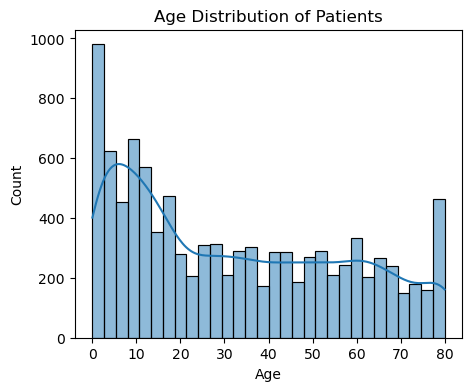

In [331]:
# Age distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(5,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


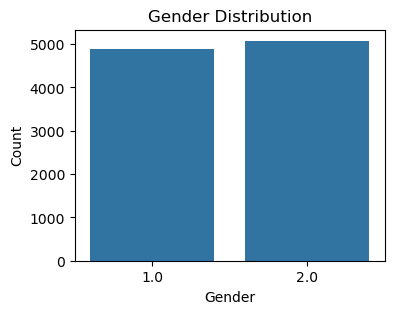

In [332]:
plt.figure(figsize=(4,3))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


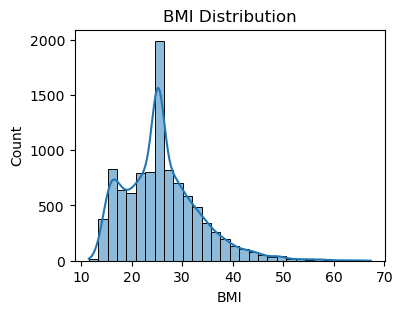

In [333]:
#BMI Distribution
plt.figure(figsize=(4,3))
sns.histplot(df['BMI'], bins=30, kde=True)
plt.title("BMI Distribution")
plt.show()

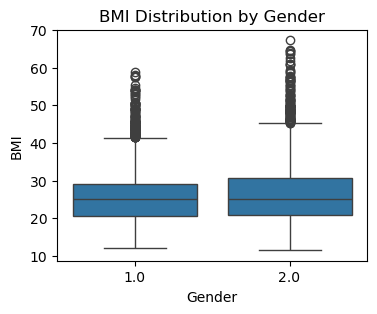

In [334]:
#BMI Distribution by Gender
plt.figure(figsize=(4,3))
sns.boxplot(x='Gender', y='BMI', data=df)
plt.title("BMI Distribution by Gender")
plt.show()


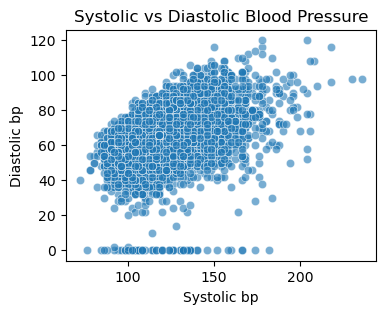

In [335]:
# Systoic Bp vs Diastolic Bp
plt.figure(figsize=(4,3))
sns.scatterplot(x='Systolic bp', y='Diastolic bp', data=df, alpha=0.6)
plt.title("Systolic vs Diastolic Blood Pressure")
plt.show()


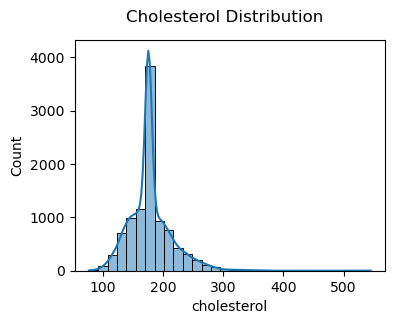

In [336]:
#Lipid profie distribution
plt.figure(figsize=(4,3))
sns.histplot(df['cholesterol'], bins=30, kde=True)
plt.suptitle("Cholesterol Distribution")
plt.show()


Text(0.5, 1.0, 'Albumin–Creatinine Ratio Distribution')

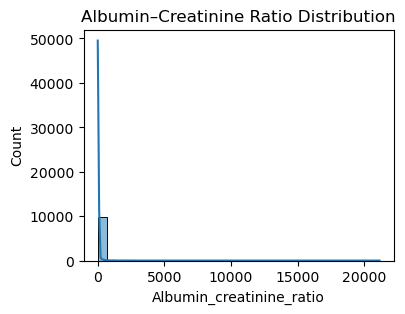

In [337]:
# Albumin-Creatinine Ratio Distribution
plt.figure(figsize=(4,3))
sns.histplot(df['Albumin_creatinine_ratio'], bins =30,kde=True)
plt.title("Albumin–Creatinine Ratio Distribution")


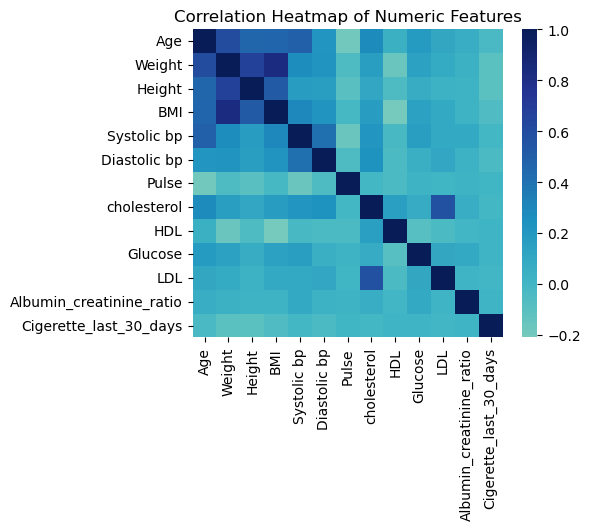

In [338]:
numeric_cols = df.select_dtypes(include='number')

plt.figure(figsize=(5,4))
sns.heatmap(
    numeric_cols.corr(),
    cmap='YlGnBu',
    center=0,
    annot=False
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


In [339]:
df['diabetes_risk']     = (df['Glucose'] > 126).astype(int)
df['hypertension_risk'] = (df['Systolic bp'] > 140).astype(int)
df['cholesterol_risk']  = (df['cholesterol'] > 200).astype(int)
df['kidney_risk']       = (df['Albumin_creatinine_ratio'] > 30).astype(int)
df['obesity_risk'] = (df['BMI'] >= 30).astype(int)
df['hdl_risk'] = (df['HDL'] < 40).astype(int)
df['ldl_risk'] = (df['LDL'] >= 130).astype(int)
df['heart_disease_risk'] = (
    df['hypertension_risk'] |
    df['ldl_risk'] |
    df['hdl_risk'] |
    df['cholesterol_risk'] |
    df['diabetes_risk'] |
    df['obesity_risk']
).astype(int)


In [340]:
y_dict = {
    "diabetes": df['diabetes_risk'],
    "hypertension": df['hypertension_risk'],
    "cholesterol": df['cholesterol_risk'],
    "kidney": df['kidney_risk'],
    "obesity": df['obesity_risk'],
    "hdl": df['hdl_risk'],
    "ldl": df['ldl_risk'],
    "heart": df['heart_disease_risk']
}


In [341]:
base_features1 = [
    'Age','Gender','Ethnicity','Education','Income',
    'Weight','Height','BMI','Pulse',
    'smoking status','Cigerette_last_30_days'
]
base_features2 = [
    'Systolic bp','Diastolic bp',
    'Glucose','cholesterol','HDL','LDL'
]
base_features3 = [
    'Albumin_creatinine_ratio'
]
base_feature1_no_bmi = [f for f in base_features1 if f != 'BMI']

X_feature_map = {
    "diabetes": base_features1 + ['cholesterol','HDL','LDL'],

    "hypertension": base_features1 + ['Systolic bp','Diastolic bp'], 

    "cholesterol": base_features1 + ['Glucose'],

    "obesity": base_feature1_no_bmi,

    "heart": base_feature1_no_bmi + ['HDL','LDL'],

    "kidney": base_features1 + base_features2,  

    "hdl": base_features1 + ['Glucose','LDL'],

    "ldl": base_features1 + ['Glucose','HDL']
}


In [342]:
X_dict = {
    disease: df[features]
    for disease, features in X_feature_map.items()
}


In [343]:
from sklearn.model_selection import train_test_split

X_train_dict = {}
X_test_dict = {}
y_train_dict = {}
y_test_dict = {}

for disease in y_dict.keys():
    X = X_dict[disease]
    y = y_dict[disease]

    X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,stratify=y,random_state=42)
    X_train_dict[disease] = X_train
    X_test_dict[disease] = X_test
    y_train_dict[disease] = y_train
    y_test_dict[disease] = y_test


In [344]:
print(X_train)

       Age Gender Ethnicity Education Income  Weight  Height  Pulse  \
5595  73.0    2.0       4.0       2.0   15.0    93.9   154.5   68.0   
8775  80.0    1.0       3.0       1.0    4.0    83.4   166.6   64.0   
8238  59.0    1.0       6.0       5.0    8.0    66.8   161.7   70.0   
950    6.0    1.0       7.0       4.0   15.0    24.3   117.0   74.0   
3460  18.0    2.0       4.0       4.0    8.0    81.1   158.1   80.0   
...    ...    ...       ...       ...    ...     ...     ...    ...   
3834   6.0    2.0       7.0       4.0    7.0    22.5   120.5   74.0   
4190  61.0    1.0       1.0       3.0    6.0   118.6   170.3   84.0   
5403   2.0    1.0       3.0       4.0    7.0    13.3    88.8   74.0   
1974  28.0    2.0       1.0       2.0   15.0    46.3   159.8   72.0   
3236  25.0    2.0       2.0       3.0    6.0   122.2   164.4   82.0   

     smoking status  Cigerette_last_30_days   HDL    LDL  
5595            1.0                    30.0  52.0  155.0  
8775            1.0          

In [345]:
print(y_train)

5595    1
8775    1
8238    1
950     0
3460    1
       ..
3834    0
4190    1
5403    0
1974    1
3236    1
Name: heart_disease_risk, Length: 7976, dtype: int32


In [346]:
y_test_dict[disease]

4443    1
448     1
5945    1
6216    1
4512    1
       ..
9169    1
9       0
5773    0
1149    0
6780    0
Name: heart_disease_risk, Length: 1995, dtype: int32

In [347]:
df.head()
    

,Age,Gender,Ethnicity,Education,Income,Weight,Height,BMI,Systolic bp,Diastolic bp,...,smoking status,Cigerette_last_30_days,diabetes_risk,hypertension_risk,cholesterol_risk,kidney_risk,obesity_risk,hdl_risk,ldl_risk,heart_disease_risk
0,62.0,1.0,3.0,5.0,10.0,94.8,184.5,27.8,128.0,70.0,...,1.0,30.0,0,0,0,0,0,0,0,0
1,53.0,1.0,3.0,3.0,4.0,90.4,171.4,30.8,146.0,88.0,...,1.0,30.0,0,1,1,0,1,0,1,1
2,78.0,1.0,3.0,3.0,5.0,83.4,170.1,28.8,138.0,46.0,...,1.0,30.0,0,0,1,1,0,1,1,1
3,56.0,2.0,3.0,5.0,10.0,109.8,160.9,42.4,132.0,72.0,...,2.0,30.0,0,0,0,0,1,0,0,1
4,42.0,2.0,4.0,4.0,7.0,55.2,164.9,20.3,100.0,70.0,...,2.0,30.0,0,0,1,0,0,0,1,1


In [348]:
numerical_features = ['Age','Height','Weight','BMI','Systolic bp','Diastolic bp','Glucose','Pulse','Albumin_creatinine_ratio','Cigeretter_last_30_days','HDL','LDL']
categorical_features = ['Education','smoking status','Gender','Income','Ethnicity']
def make_preprocessor(feature_list):
    numeric_cols = [c for c in feature_list if c in numerical_features]
    categorical_cols = [c for c in feature_list if c in categorical_features]

    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
        ]
    )

In [349]:
print(df.head())

    Age Gender Ethnicity Education Income  Weight  Height   BMI  Systolic bp  \
0  62.0    1.0       3.0       5.0   10.0    94.8   184.5  27.8        128.0   
1  53.0    1.0       3.0       3.0    4.0    90.4   171.4  30.8        146.0   
2  78.0    1.0       3.0       3.0    5.0    83.4   170.1  28.8        138.0   
3  56.0    2.0       3.0       5.0   10.0   109.8   160.9  42.4        132.0   
4  42.0    2.0       4.0       4.0    7.0    55.2   164.9  20.3        100.0   

   Diastolic bp  ...  smoking status  Cigerette_last_30_days  diabetes_risk  \
0          70.0  ...             1.0                    30.0              0   
1          88.0  ...             1.0                    30.0              0   
2          46.0  ...             1.0                    30.0              0   
3          72.0  ...             2.0                    30.0              0   
4          70.0  ...             2.0                    30.0              0   

   hypertension_risk  cholesterol_risk  kidn

In [350]:
Model = {}

for disease in y_dict.keys():
    
    preprocessor = make_preprocessor(X_train_dict[disease].columns)

    if disease == "hypertension":
        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=4,
            min_samples_leaf=50,
            random_state=42,
            n_jobs=-1
        )
    else:
        model = BalancedRandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=10,
        min_samples_split=30,
        bootstrap=False,           
        sampling_strategy="all",    
        replacement=True,           
        random_state=42,
        n_jobs=-1
        )

    Model[disease] = Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    Model[disease].fit(
        X_train_dict[disease],
        y_train_dict[disease]
    )


In [351]:
def get_high_threshold(disease):
    if disease == "diabetes":
        return 0.70
    elif disease == "cholesterol":
        return 0.65
    elif disease == "kidney":
        return 0.60
    elif disease == "hdl":
        return 0.65
    elif disease == "ldl":
        return 0.70
    elif disease == "hypertension":
        return 0.50
    elif disease == "heart":
        return 0.65
    elif disease == "obesity":
        return 0.55
    else:
        return 0.60  


In [352]:
high_th = get_high_threshold(disease)
low_th = 0.5 * high_th


In [353]:
risk_scores = {}
for disease, model in Model.items():
    risk_scores[disease] = model.predict_proba(X_test_dict[disease])[:, 1]


In [354]:
risk_labels = {}

for disease, probs in risk_scores.items():
    
    high_th = get_high_threshold(disease)
    low_th = 0.5 * high_th

    risk_labels[disease] = np.where(
        probs >= high_th,
        "High Risk",
        np.where(
            probs >= low_th,
            "Medium Risk",
            "Low Risk"
        )
    )


In [355]:
results = pd.DataFrame()

for disease in risk_scores.keys():
    results[f"{disease}_risk_score"] = risk_scores[disease]
    results[f"{disease}_risk_label"] = risk_labels[disease]


In [356]:
    recommendation_db = {

    "diabetes": """
        Recommend HbA1c or fasting blood glucose test for confirmation
        Limit intake of refined sugars and sweetened beverages
        Increase physical activity to at least 30 minutes per day
        Adopt a balanced diet with controlled carbohydrate portions
        Weight management if BMI is elevated
        Regular annual blood glucose monitoring
    """,

    "hypertension": """
        Regular blood pressure monitoring
        Reduce salt and processed food intake
        Maintain healthy sleep and stress management routines
        Engage in regular aerobic physical activity
        Limit alcohol consumption if applicable

    """,

    "cholesterol": """
        Repeat lipid profile testing as recommended
        Reduce intake of saturated and trans fats
        Increase dietary fiber (fruits, vegetables, whole grains)
        Engage in regular physical exercise
        Limit fried and processed foods
        Maintain a heart-healthy diet
    """,

    "kidney": """
        Repeat urine albumin-creatinine ratio test
        Maintain adequate daily hydration
        Monitor blood pressure and blood glucose levels
        Limit excessive protein and salt intake if advised
        Avoid unnecessary or prolonged use of painkillers
    """,

    "heart": """
        Comprehensive cardiovascular risk assessment
        Monitor and manage blood pressure, cholesterol, and glucose
        Increase physical activity and reduce sedentary behavior
        Adopt a heart-healthy diet (low salt, low saturated fat)
        Smoking cessation if applicable
    """,

    "obesity": """
        Structured weight management and lifestyle plan
        Balanced calorie intake with portion control
        Increase physical activity and daily movement
        Limit sugary drinks and high-calorie snacks
        Monitor BMI and weight periodically
        Adopt sustainable eating habits
    """,

    "hdl": """
        Increase physical activity to improve HDL levels
        Include healthy fats such as nuts, seeds, and fish
        Reduce intake of processed and fried foods
        Avoid smoking and excessive alcohol consumption
        Periodic lipid profile monitoring
        Maintain balanced nutrition
    """,

    "ldl": """
        Reduce saturated and trans fat intake
        Increase fiber-rich foods such as fruits and vegetables
        Engage in regular aerobic exercise
        Maintain healthy body weight
        Periodic lipid profile testing
        Adopt heart-healthy eating habits
    """
}


In [357]:
vectorizer = TfidfVectorizer(stop_words='english')
rec_texts = list(recommendation_db.values())
rec_vectors = vectorizer.fit_transform(rec_texts)

def get_recommendations(patient_conditions):
    results = []
    for condition in patient_conditions:
        if condition in recommendation_db:
            results.append((condition, recommendation_db[condition]))
    return results


In [358]:
results

,diabetes_risk_score,diabetes_risk_label,hypertension_risk_score,hypertension_risk_label,cholesterol_risk_score,cholesterol_risk_label,kidney_risk_score,kidney_risk_label,obesity_risk_score,obesity_risk_label,hdl_risk_score,hdl_risk_label,ldl_risk_score,ldl_risk_label,heart_risk_score,heart_risk_label
0,0.618752,Medium Risk,0.013915,Low Risk,0.368323,Medium Risk,0.178100,Low Risk,0.728491,High Risk,0.350619,Medium Risk,0.433567,Medium Risk,0.891082,High Risk
1,0.021333,Low Risk,0.045400,Low Risk,0.376524,Medium Risk,0.367556,Medium Risk,0.923956,High Risk,0.213314,Low Risk,0.002821,Low Risk,0.702942,High Risk
2,0.155073,Low Risk,0.015543,Low Risk,0.505351,Medium Risk,0.451482,Medium Risk,0.202093,Low Risk,0.587581,Medium Risk,0.348228,Low Risk,0.972470,High Risk
3,0.541582,Medium Risk,0.076480,Low Risk,0.009773,Low Risk,0.439497,Medium Risk,0.338919,Medium Risk,0.217407,Low Risk,0.705662,High Risk,0.856291,High Risk
4,0.170150,Low Risk,0.007479,Low Risk,0.668998,High Risk,0.258009,Low Risk,0.049342,Low Risk,0.438186,Medium Risk,0.036485,Low Risk,0.934133,High Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1990,0.331343,Low Risk,0.604171,High Risk,0.133975,Low Risk,0.228762,Low Risk,0.481011,Medium Risk,0.166221,Low Risk,0.368997,Medium Risk,0.658395,High Risk
1991,0.461400,Medium Risk,0.102629,Low Risk,0.501008,Medium Risk,0.112372,Low Risk,0.258390,Low Risk,0.012808,Low Risk,0.374449,Medium Risk,0.428995,Medium Risk
1992,0.726817,High Risk,0.628162,High Risk,0.612950,Medium Risk,0.618085,High Risk,0.009627,Low Risk,0.659680,High Risk,0.355584,Medium Risk,0.142090,Low Risk
1993,0.010522,Low Risk,0.047684,Low Risk,0.160931,Low Risk,0.597953,Medium Risk,0.893164,High Risk,0.026324,Low Risk,0.003322,Low Risk,0.123671,Low Risk


In [359]:
def evaluate_rf_model(model,X_train_dict,y_train, X_test_dict, y_test, risk_prob_col, model_name):

    y_train_pred = model.predict(X_train_dict)
    y_test_pred = model.predict(X_test_dict)
    
    
    y_prob = risk_prob_col
    
    
    print(f" {model_name} ")
    print("Train_Accuracy:",accuracy_score(y_train,y_train_pred))
    print("Test_Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Precision:", precision_score(y_test, y_test_pred))
    print("Recall:", recall_score(y_test, y_test_pred))
    print("F1-score:", f1_score(y_test, y_test_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    
    cm = confusion_matrix(y_test, y_test_pred)
    print("Confusion Matrix:\n", cm)
    print("\n")

evaluate_rf_model(Model["diabetes"],   X_train_dict["diabetes"],   y_train_dict["diabetes"],  X_test_dict["diabetes"],    y_test_dict["diabetes"],    results['diabetes_risk_score'],    "Diabetes")  
evaluate_rf_model(Model["hypertension"],    X_train_dict["hypertension"],   y_train_dict["hypertension"],    X_test_dict["hypertension"],  y_test_dict["hypertension"],  results['hypertension_risk_score'],  "Hypertension")
evaluate_rf_model(Model["cholesterol"],   X_train_dict["cholesterol"],   y_train_dict["cholesterol"],  X_test_dict["cholesterol"],   y_test_dict["cholesterol"],   results['cholesterol_risk_score'],   "Cholesterol")
evaluate_rf_model(Model["kidney"],   X_train_dict["kidney"]    ,y_train_dict["kidney"],    X_test_dict["kidney"],   y_test_dict["kidney"],   results['kidney_risk_score'],   "Kidney")
evaluate_rf_model(Model["heart"],    X_train_dict["heart"],  y_train_dict["heart"],   X_test_dict["heart"],   y_test_dict["heart"],   results['heart_risk_score'],   "Heart")
evaluate_rf_model(Model["obesity"],   X_train_dict["obesity"],  y_train_dict["obesity"],   X_test_dict["obesity"],  y_test_dict["obesity"],  results['obesity_risk_score'],  "Obesity")
evaluate_rf_model(Model["hdl"],    X_train_dict["hdl"],   y_train_dict["hdl"],    X_test_dict["hdl"],   y_test_dict["hdl"],   results['hdl_risk_score'],  "HDL")
evaluate_rf_model(Model["ldl"],    X_train_dict["ldl"],   y_train_dict["ldl"],    X_test_dict["ldl"],   y_test_dict["ldl"],   results['ldl_risk_score'],  "LDL")


 Diabetes 
Train_Accuracy: 0.7594032096288866
Test_Accuracy: 0.7518796992481203
Precision: 0.11355311355311355
Recall: 0.8493150684931506
F1-score: 0.20032310177705978
ROC-AUC: 0.8953501632146879
Confusion Matrix:
 [[1438  484]
 [  11   62]]


 Hypertension 
Train_Accuracy: 0.9997492477432297
Test_Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
ROC-AUC: 1.0
Confusion Matrix:
 [[1811    0]
 [   0  184]]


 Cholesterol 
Train_Accuracy: 0.6841775325977933
Test_Accuracy: 0.6912280701754386
Precision: 0.38643702906350913
Recall: 0.8864197530864197
F1-score: 0.5382308845577212
ROC-AUC: 0.817829023992546
Confusion Matrix:
 [[1020  570]
 [  46  359]]


 Kidney 
Train_Accuracy: 0.7137662988966901
Test_Accuracy: 0.6952380952380952
Precision: 0.20919881305637983
Recall: 0.6527777777777778
F1-score: 0.31685393258426964
ROC-AUC: 0.7474835009264464
Confusion Matrix:
 [[1246  533]
 [  75  141]]


 Heart 
Train_Accuracy: 0.9097291875626881
Test_Accuracy: 0.8887218045112782
Precision: 0.83069306

In [360]:
#scaled_data

In [361]:
Model = {}

for disease in y_dict.keys():
    preprocessor = make_preprocessor(X_train_dict[disease].columns)
    
    model = LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',  
        n_jobs=-1
    )

    Model[disease] = Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    Model[disease].fit(
        X_train_dict[disease],
        y_train_dict[disease]
    )


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='

In [362]:
def evaluate_lr_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    n_classes = len(np.unique(y_test))

    print(f" {model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision (macro):", precision_score(y_test, y_pred, average='macro'))
    print("Recall (macro):", recall_score(y_test, y_pred, average='macro'))
    print("F1-score (macro):", f1_score(y_test, y_pred, average='macro'))

    
    if n_classes == 2:
        roc_auc = roc_auc_score(y_test, y_prob[:, 1])
    else:
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')

    print("ROC-AUC:", roc_auc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\n")


In [363]:
evaluate_lr_model(Model["diabetes"], X_test_dict["diabetes"], y_test_dict["diabetes"], "Diabetes")
evaluate_lr_model(Model["hypertension"], X_test_dict["hypertension"], y_test_dict["hypertension"], "Hypertension")
evaluate_lr_model(Model["cholesterol"], X_test_dict["cholesterol"], y_test_dict["cholesterol"], "Cholesterol")
evaluate_lr_model(Model["kidney"], X_test_dict["kidney"], y_test_dict["kidney"], "Kidney")
evaluate_lr_model(Model["heart"], X_test_dict["heart"], y_test_dict["heart"], "Heart")
evaluate_lr_model(Model["obesity"], X_test_dict["obesity"], y_test_dict["obesity"], "Obesity")
evaluate_lr_model(Model["hdl"], X_test_dict["hdl"], y_test_dict["hdl"], "HDL")
evaluate_lr_model(Model["ldl"], X_test_dict["ldl"], y_test_dict["ldl"], "LDL")


 Diabetes
Accuracy: 0.7258145363408521
Precision (macro): 0.5468857189459394
Recall (macro): 0.7786302795318802
F1-score (macro): 0.5088261545296071
ROC-AUC: 0.8439125910509886
Confusion Matrix:
 [[1387  535]
 [  12   61]]


 Hypertension
Accuracy: 0.9894736842105263
Precision (macro): 0.948780487804878
Recall (macro): 0.9942020982882385
F1-score (macro): 0.9700918553757918
ROC-AUC: 1.0
Confusion Matrix:
 [[1790   21]
 [   0  184]]


 Cholesterol
Accuracy: 0.6902255639097744
Precision (macro): 0.6462244879009045
Recall (macro): 0.7200908455625437
F1-score (macro): 0.6387623146214374
ROC-AUC: 0.7664088826772265
Confusion Matrix:
 [[1065  525]
 [  93  312]]


 Kidney
Accuracy: 0.6511278195488722
Precision (macro): 0.5628750728348382
Recall (macro): 0.653886390606458
F1-score (macro): 0.5292833412434741
ROC-AUC: 0.6954879978348218
Confusion Matrix:
 [[1157  622]
 [  74  142]]


 Heart
Accuracy: 0.8451127819548873
Precision (macro): 0.843008335438242
Recall (macro): 0.845205653566526
F1-sc

In [364]:
import pickle

with open('models.pkl', 'wb') as f:
    pickle.dump(models, f)

with open('scaler_dict.pkl', 'wb') as f:
    pickle.dump(scaler_dict, f)

with open('oe.pkl', 'wb') as f:
    pickle.dump(oe, f)

feature_lists = {disease: list(X_dict[disease].columns) for disease in X_dict.keys()}
with open('X_dict_features.pkl', 'wb') as f:
    pickle.dump(feature_lists, f)

with open('recommendation_db.pkl', 'wb') as f:
    pickle.dump(recommendation_db, f)

print("All models and preprocessors saved successfully!")
print("Files created:")
print("  models.pkl")
print("  scaler_dict.pkl")
print("  oe.pkl")
print("  X_dict_features.pkl")
print("  recommendation_db.pkl")



NameError: name 'models' is not defined